# Limpieza de datos: Libere - Reto06

**CARGA DE LIBRERIAS**

In [131]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import os
import datetime as datetime

**DESCARGA DE DATOS**

In [132]:
path = os.path.join('Datos', 'Originales', 'cancellation_data_for_mondragon_unibertsitatea_2024.csv')
df = pd.read_csv(path)

**Analizar Datos**

In [133]:
df.head()

,booked_at,checkin_time,checkout_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,...,recurrence,libere_community,bought_products,product_count,reservation_net_value,total_adr,status,cancelled_at,cancellation_reason,cancellation_lead_time
0,"Nov 26, 2022, 16:10","Jan 1, 2023, 12:00","Jan 2, 2023, 12:00",36,1,January,Sunday,1,0,channel_manager,...,4,no,no,0,15.92,15.92,checked_out,NaN,NaN,NaN
1,"Dec 21, 2022, 17:27","Jan 1, 2023, 13:09","Jan 10, 2023, 12:00",11,9,January,Sunday,1,0,channel_manager,...,2,yes,no,0,117.78,13.09,checked_out,NaN,NaN,NaN
2,"Sep 21, 2022, 19:46","Jan 1, 2023, 15:00","Jan 7, 2023, 12:00",102,6,January,Sunday,2,4,channel_manager,...,1,no,yes,8,755.65,125.94,checked_out,NaN,NaN,NaN
3,"Sep 24, 2022, 12:09","Jan 1, 2023, 15:00","Jan 2, 2023, 12:00",99,1,January,Sunday,2,2,channel_manager,...,1,no,yes,1,186.37,186.37,checked_out,NaN,NaN,NaN
4,"Oct 18, 2022, 07:12","Jan 1, 2023, 15:00","Jan 2, 2023, 12:00",75,1,January,Sunday,4,0,channel_manager,...,1,no,no,0,77.02,77.02,checked_out,NaN,NaN,NaN


In [134]:
df.shape

(56448, 36)

In [135]:
df.columns

Index(['booked_at', 'checkin_time', 'checkout_time', 'lead_time',
       'lenght_of_stay', 'checkin_month', 'checkin_day', 'adult_count',
       'child_count', 'origin', 'travel_agency_name', 'requested_category',
       'requested_category_name', 'asset', 'asset_type', 'brand',
       'asset_opening_date', 'available_units', 'business_segment', 'rate',
       'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'last_entry_form_completed_at',
       'returning_inhabitant', 'recurrence', 'libere_community',
       'bought_products', 'product_count', 'reservation_net_value',
       'total_adr', 'status', 'cancelled_at', 'cancellation_reason',
       'cancellation_lead_time'],
      dtype='object')

In [136]:
df.dtypes

booked_at                        object
checkin_time                     object
checkout_time                    object
lead_time                         int64
lenght_of_stay                    int64
checkin_month                    object
checkin_day                      object
adult_count                       int64
child_count                       int64
origin                           object
travel_agency_name               object
requested_category               object
requested_category_name          object
asset                            object
asset_type                       object
brand                            object
asset_opening_date               object
available_units                   int64
business_segment                 object
rate                             object
rate_group_name                  object
rate_type                        object
completed_entry_forms_count     float64
all_entry_forms_completed        object
last_entry_form_completed_at     object


**1) Conversión de Fechas a tipo Fecha**

In [137]:
#Convertir a tipo fecha, las variables de fechas
formato = "%b %d, %Y, %H:%M"

df["booked_at"] = pd.to_datetime(df["booked_at"], format=formato, errors="coerce")
df["checkin_time"] = pd.to_datetime(df["checkin_time"], format=formato, errors="coerce")
df["checkout_time"] = pd.to_datetime(df["checkout_time"], format=formato, errors="coerce")
df["asset_opening_date"] = pd.to_datetime(df["asset_opening_date"], format=formato, errors="coerce")
df["last_entry_form_completed_at"] = pd.to_datetime(df["last_entry_form_completed_at"], format = formato, errors="coerce")
df["cancelled_at"] = pd.to_datetime(df["cancelled_at"], format = formato, errors="coerce")

#Convertir a numerico:
columnas_numericas = ['lenght_of_stay','adult_count','child_count','completed_entry_forms_count','product_count','total_adr','cancellation_lead_time']

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [138]:
df.dtypes

booked_at                       datetime64[ns]
checkin_time                    datetime64[ns]
checkout_time                   datetime64[ns]
lead_time                                int64
lenght_of_stay                           int64
checkin_month                           object
checkin_day                             object
adult_count                              int64
child_count                              int64
origin                                  object
travel_agency_name                      object
requested_category                      object
requested_category_name                 object
asset                                   object
asset_type                              object
brand                                   object
asset_opening_date              datetime64[ns]
available_units                          int64
business_segment                        object
rate                                    object
rate_group_name                         object
rate_type    

**2) Analizar DUPLICADOS**
#### Los eliminaremos antes de hacer las imputaciones

In [139]:
df.duplicated().sum()# Numero de duplicados

np.int64(4547)

In [140]:
print(df)

      booked_at checkin_time checkout_time  lead_time  lenght_of_stay  \
0           NaT          NaT           NaT         36               1   
1           NaT          NaT           NaT         11               9   
2           NaT          NaT           NaT        102               6   
3           NaT          NaT           NaT         99               1   
4           NaT          NaT           NaT         75               1   
...         ...          ...           ...        ...             ...   
56443       NaT          NaT           NaT         79               1   
56444       NaT          NaT           NaT         79               1   
56445       NaT          NaT           NaT         75               1   
56446       NaT          NaT           NaT         75               1   
56447       NaT          NaT           NaT          1               2   

      checkin_month checkin_day  adult_count  child_count           origin  \
0           January      Sunday            1 

In [141]:
#Filas duplicadas
df[df.duplicated()]

,booked_at,checkin_time,checkout_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,...,recurrence,libere_community,bought_products,product_count,reservation_net_value,total_adr,status,cancelled_at,cancellation_reason,cancellation_lead_time
38,NaT,NaT,NaT,39,2,January,Monday,1,0,channel_manager,...,1,no,no,0,20.94,10.47,checked_out,NaT,NaN,NaN
63,NaT,NaT,NaT,1,1,January,Monday,1,0,channel_manager,...,1,no,yes,1,25.16,25.16,cancelled,NaT,refuse_to_detail,0.0
65,NaT,NaT,NaT,1,1,January,Monday,1,0,channel_manager,...,1,no,yes,1,25.16,25.16,cancelled,NaT,refuse_to_detail,0.0
66,NaT,NaT,NaT,1,1,January,Monday,1,0,channel_manager,...,1,no,no,0,21.07,21.07,cancelled,NaT,refuse_to_detail,0.0
83,NaT,NaT,NaT,121,3,January,Wednesday,4,0,email,...,1,no,yes,4,274.53,91.51,checked_out,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56182,NaT,NaT,NaT,265,2,November,Thursday,2,0,channel_manager,...,1,no,no,0,430.79,215.40,cancelled,NaT,changed_plans,257.0
56217,NaT,NaT,NaT,13,1,November,Saturday,1,3,channel_manager,...,1,no,no,0,198.03,198.03,checked_out,NaT,NaN,NaN
56422,NaT,NaT,NaT,97,2,December,Saturday,6,0,channel_manager,...,1,no,yes,1,474.78,237.39,checked_out,NaT,NaN,NaN
56425,NaT,NaT,NaT,73,2,December,Saturday,2,0,channel_manager,...,1,no,no,0,397.27,198.64,checked_out,NaT,NaN,NaN


In [142]:
#Quedarnos con el df limpio sin duplicados
df= df.drop_duplicates()
print(df.shape)

(51901, 36)


**3) Analizar MISSINGS (Valores NA)**

In [143]:
df.isna()

,booked_at,checkin_time,checkout_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,...,recurrence,libere_community,bought_products,product_count,reservation_net_value,total_adr,status,cancelled_at,cancellation_reason,cancellation_lead_time
0,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
1,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
2,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
3,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
4,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56442,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
56443,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
56445,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
56446,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True


In [144]:
#Numero de NA-s  por cada columna
tabla_nas_columnas = df.isna().sum(axis = 0).reset_index(name="N_Nas").sort_values("N_Nas",ascending=False)
tabla_nas_columnas = tabla_nas_columnas[tabla_nas_columnas["N_Nas"]>0]
tabla_nas_columnas

,index,N_Nas
0,booked_at,51901
1,checkin_time,51901
2,checkout_time,51901
16,asset_opening_date,51901
33,cancelled_at,51901
24,last_entry_form_completed_at,51901
35,cancellation_lead_time,39267
34,cancellation_reason,39267
10,travel_agency_name,15676
22,completed_entry_forms_count,1573


In [145]:
#Numero de NA-s por cada fila
df.isna().sum(axis = 1).reset_index(name="N_Nas").sort_values("N_Nas",ascending=False)

,index,N_Nas
41577,45591,10
44141,48364,10
32588,36122,10
49340,53820,10
47160,51559,10
...,...,...
12390,14579,6
12387,14576,6
40003,43872,6
40001,43870,6


<Axes: >

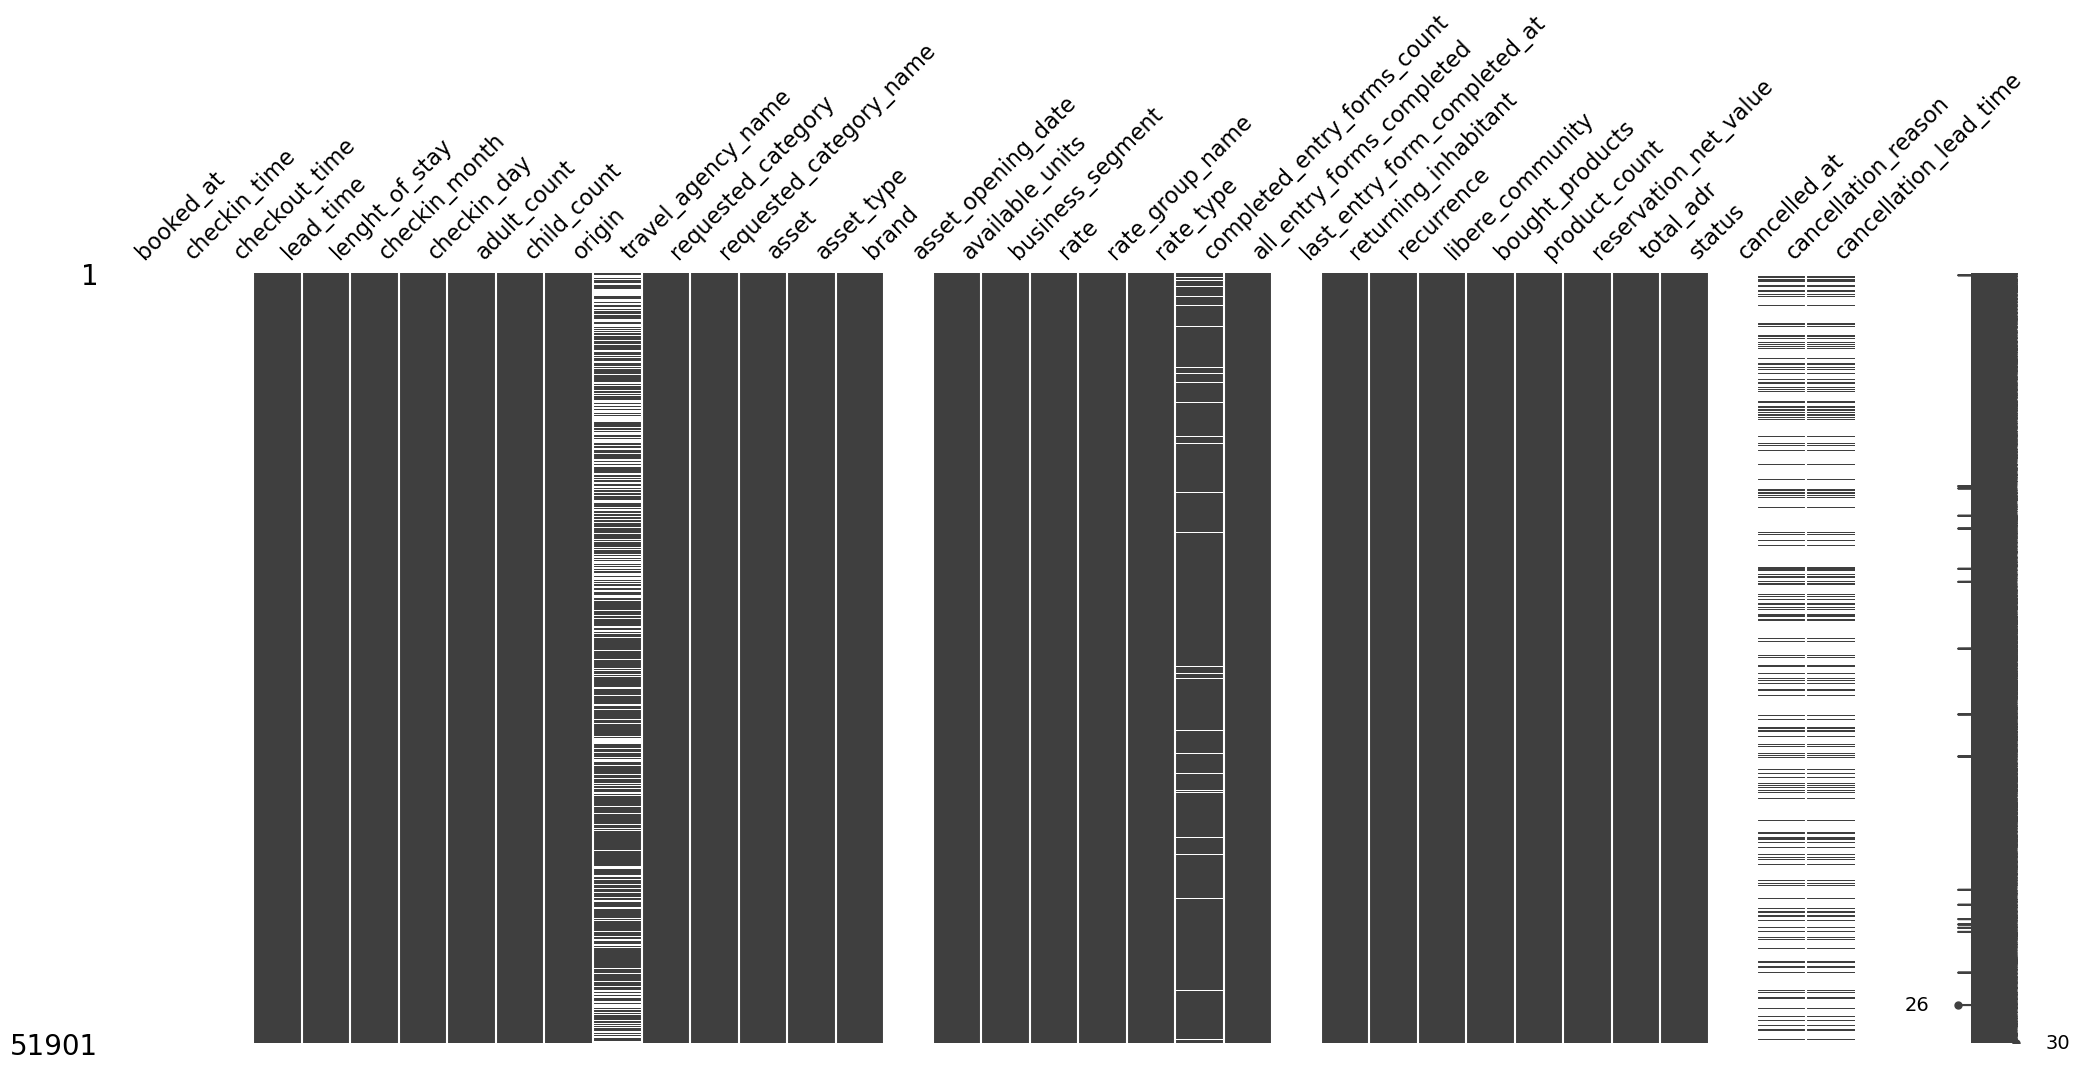

In [146]:
#Visualizar la distribucion de los NA-s
msno.matrix(df)

<Axes: >

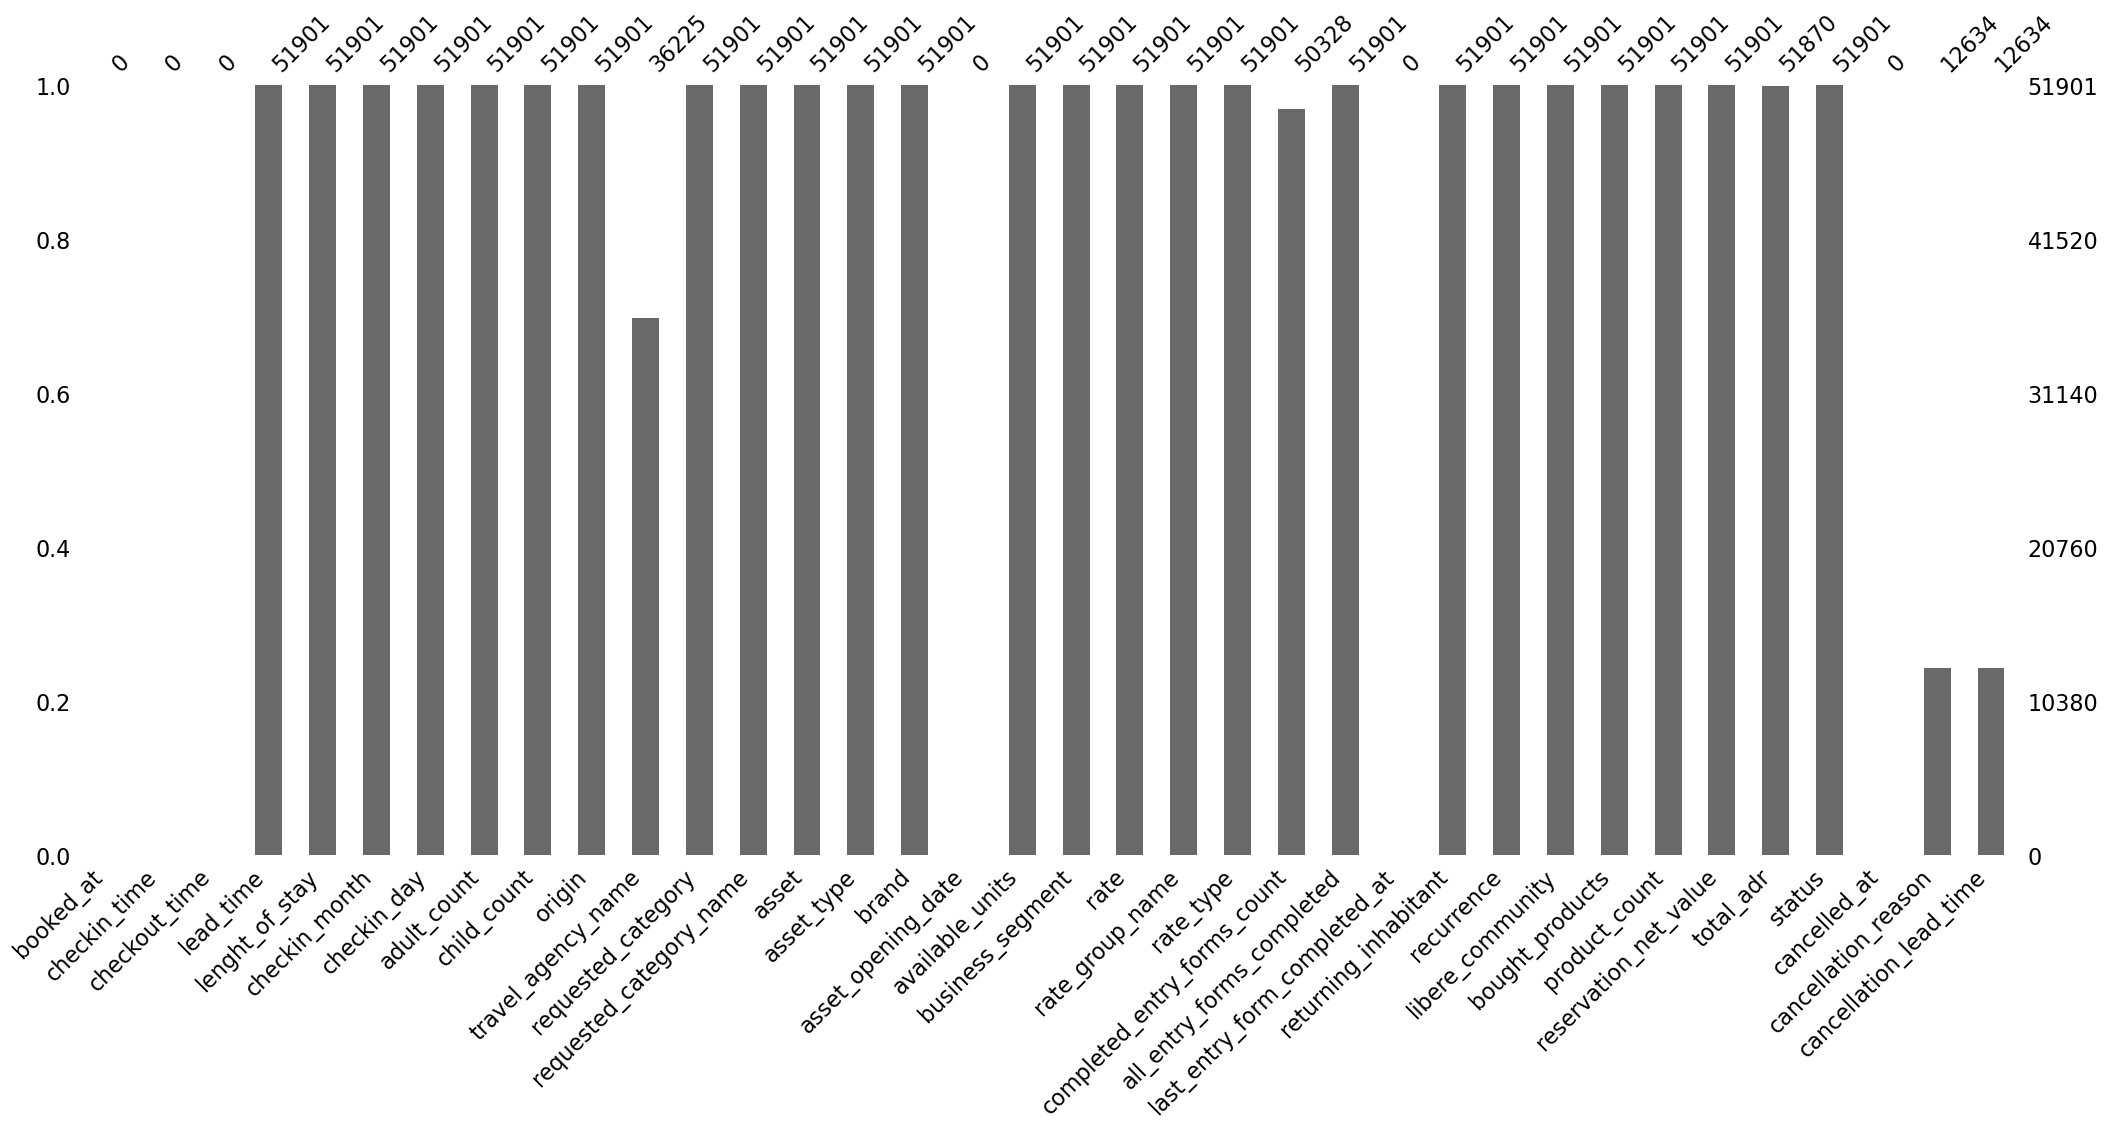

In [147]:
msno.bar(df) # Instancias completas

3.1) Correlación entre missings

<Axes: >

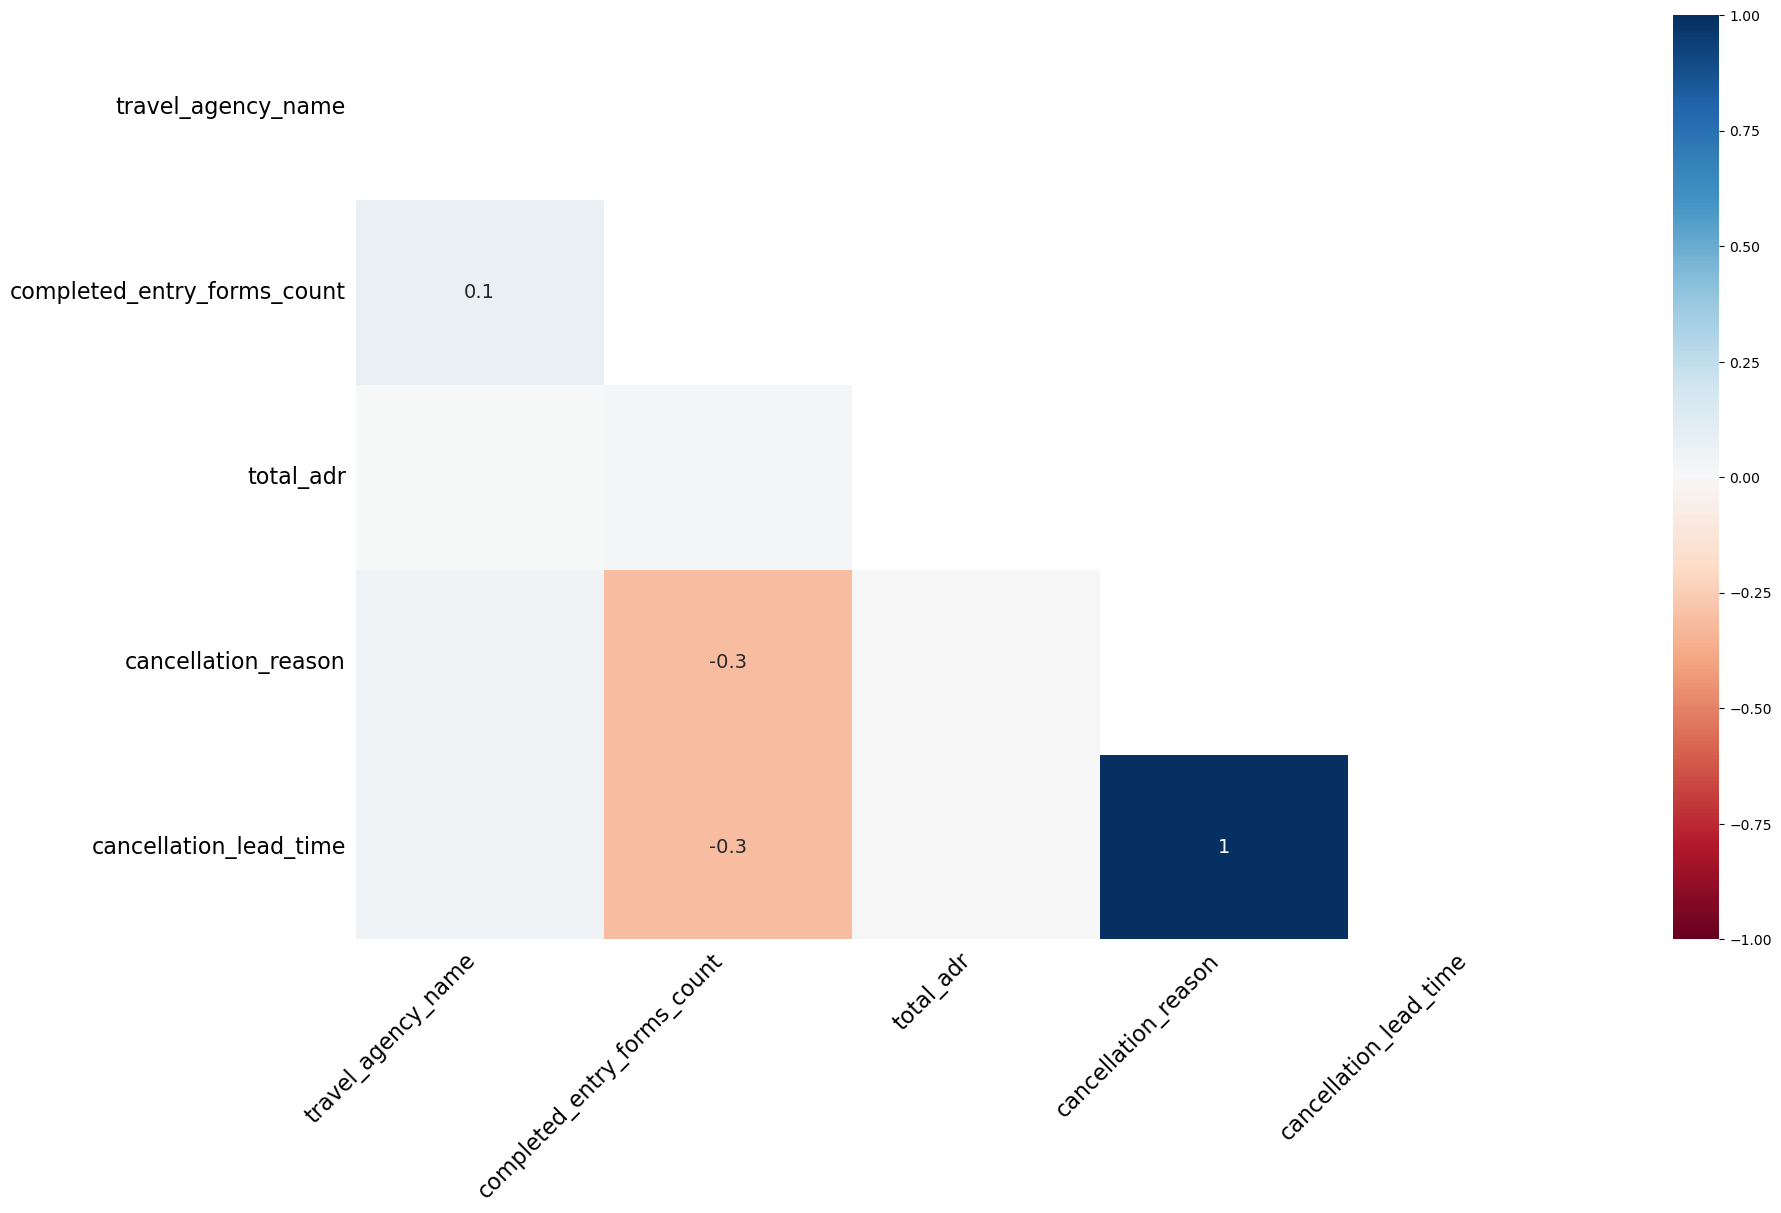

In [148]:
msno.heatmap(df) 

**4) Tratamientos de MISSINGS**

### -------   IMPUTACIONES  de las Variables con NA-s

##### 4.1) Imputacion Variables: `Cancellation_reason, Cancellation_lead_time, Cancelled_at`
##### (Las hemos imputado con "not_cancelled" o como una fecha neutral (21990-01-01))

In [149]:
#Rellenar los NA de estas columnas con "not_cancelled" o "0"
df["cancellation_reason"].fillna("not_cancelled", inplace=True)
df["cancellation_lead_time"].fillna(0, inplace=True)


C:\Users\jonba\AppData\Local\Temp\ipykernel_43984\1622217918.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["cancellation_reason"].fillna("not_cancelled", inplace=True)
C:\Users\jonba\AppData\Local\Temp\ipykernel_43984\1622217918.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

##### 4.2) Imputacion Variable: `travel_agency`
###### Tras analizar los NA de esta varibales se ha concluido que es por la razon de que la reserva se ha realizado, en persona,email,telefono..


In [150]:
df["travel_agency_name"].fillna("agency_no_registrada", inplace=True)


C:\Users\jonba\AppData\Local\Temp\ipykernel_43984\1324663103.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["travel_agency_name"].fillna("agency_no_registrada", inplace=True)


##### 4.3) Imputacion Variable: `completed_entry_forms_count`
###### Se imputó según `all_entry_forms_completed`. Si esta era "no", significa que no se ha completado ningún informe, por lo que asignamos 0.Ademas se ha actualizado "all_entry_forms_completed" a "yes" si hay algún informe completado



In [151]:
#Imputar los valores NA-s:
df.loc[df["all_entry_forms_completed"] == "no", "completed_entry_forms_count"] = 0

In [152]:
#Identificar los que "all_entry_forms_completed" son "no" pero han realizado algun test, es decir, que "completed_entry_forms_count" != 0
df.loc[df["completed_entry_forms_count"] > 0, "all_entry_forms_completed"] = "yes"

#Comprobar que se ha realizado correctamente:
cantidad_no_no0 = df[(df["completed_entry_forms_count"] > 0) & (df["all_entry_forms_completed"] == "no")].shape[0]
print(f'Quedan {cantidad_no_no0} de casos en el que "completed_entry_forms" es mayor que 0 y "all_entry_forms" y es igual a "no". Por lo que esta correctamnete hecho!')

Quedan 0 de casos en el que "completed_entry_forms" es mayor que 0 y "all_entry_forms" y es igual a "no". Por lo que esta correctamnete hecho!


##### 4.6) Imputacion Variable: `total_adr`
###### Solo hay un NA-s y se ha imputado como 0 debido a que la variable "reservation_net_value" era 0

In [153]:
#Hay un NA en esta variable y es devido a que la variable "reservation_net_value" es 0. POr loq eu esta tmabien se imputara como 0
df["total_adr"].fillna(0, inplace=True)

C:\Users\jonba\AppData\Local\Temp\ipykernel_43984\4265627916.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_adr"].fillna(0, inplace=True)


In [154]:
#Comprobacion de si siguen quedando NA-s
#Las columnas con más NAs
tabla_nas_columnas1 =  df.isna().sum()#Muestra cuantas columnas tienen NA
tabla_nas_columnas1 [tabla_nas_columnas1>0]

booked_at                       51901
checkin_time                    51901
checkout_time                   51901
asset_opening_date              51901
last_entry_form_completed_at    51901
cancelled_at                    51901
dtype: int64

################################################################################################

##### Creacion nueva columna (Localicacion Hotel Reserva)

In [155]:
mapeo_ciudades = {
    'Koisi Hostel': 'Donostia',
    'Líbere Vitoria': 'Vitoria',
    'Líbere Bilbao Museo': 'Bilbao',
    'Líbere Bilbao La Vieja': 'Bilbao',
    'Líbere Valencia Abastos': 'Valencia',
    'Líbere Valencia Jardín Botánico': 'Valencia',
    'Líbere Madrid Palacio Real': 'Madrid',
    'Líbere Málaga Teatro Romano': 'Málaga',
    'Líbere Granada Catedral': 'Granada',
    'Líbere Málaga la Merced': 'Málaga',
    'Líbere Córdoba Patio Santa Marta': 'Córdoba',
    'Líbere Pamplona Yamaguchi': 'Pamplona'
}
df['City'] = df['asset'].map(mapeo_ciudades)

In [156]:
df.duplicated().sum()

np.int64(441)

# LIMPIEZA MAS EXTENSA

##### Creacion Columna : Dia de la Semana

In [157]:
df["Reserva_Dia_Semana"] = df["booked_at"].dt.day_name()
df["Cancelacion_Dia_Semana"] = df["cancelled_at"].dt.day_name()

##### Creacion Columna: Estacion (Reserva / Estancia / Cancelacion)

In [158]:
def mes_a_estacion(mes):
    if mes in [12, 1, 2]:
        return 'Winter'
    elif mes in [3, 4, 5]:
        return 'Spring'
    elif mes in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Estacion_Cancelacion'] = df['cancelled_at'].dt.month.apply(mes_a_estacion)
df['Estacion_Estancia'] = df['checkin_time'].dt.month.apply(mes_a_estacion)
df['Estacion_Reserva'] = df['booked_at'].dt.month.apply(mes_a_estacion)

In [159]:
print(df.head(10))

  booked_at checkin_time checkout_time  lead_time  lenght_of_stay  \
0       NaT          NaT           NaT         36               1   
1       NaT          NaT           NaT         11               9   
2       NaT          NaT           NaT        102               6   
3       NaT          NaT           NaT         99               1   
4       NaT          NaT           NaT         75               1   
5       NaT          NaT           NaT         37               1   
6       NaT          NaT           NaT         36               2   
7       NaT          NaT           NaT         30               1   
8       NaT          NaT           NaT         28               2   
9       NaT          NaT           NaT         21               7   

  checkin_month checkin_day  adult_count  child_count           origin  ...  \
0       January      Sunday            1            0  channel_manager  ...   
1       January      Sunday            1            0  channel_manager  ...   
2  

##### Analizar zona roja de cancelaciones
*Zona Roja Mensual* : Agosto, Mayo, Junio      //////
*Zona Roja Estacional* : Primavera

Se han creado dos variables nuevas; si la cancelacion se ha realizado en uno de esos meses o estacion el valor es 1, en caso contrario 0.

### Cálculo del ratio de cancelación por Mes / Estacion

Este bloque calcula la **proporción de cancelaciones por mes**.  
- Primero, se agrupa las reservas por `checkin_month`.  
- Luego se cuenta:
  - `Canceladas`: número de reservas con `status = 'cancelled'`.  
  - `Total_Reservas`: número total de reservas en ese mes.  
- A continuación, se calcula el **Ratio_Cancelacion** como `Canceladas / Total_Reservas`.  
- Finalmente, se ordena de mayor a menor para identificar los meses con mayor riesgo de cancelación, que se usarán para definir la **zona roja de cancelaciones**.


In [160]:
#-----Cálculo de ratio de cancelación por mes
# Cancelaciones / Total reservas por mes
cancel_ratio_month = (
    df.groupby("checkin_month")
    .agg(
        Canceladas=("status", lambda x: (x == "cancelled").sum()),
        Total_Reservas=("status", "count")
    )
    .assign(Ratio_Cancelacion=lambda x: x["Canceladas"] / x["Total_Reservas"])
    .sort_values("Ratio_Cancelacion", ascending=False)
)

print("\nRatio de cancelación por mes:")
print(cancel_ratio_month)



Ratio de cancelación por mes:
               Canceladas  Total_Reservas  Ratio_Cancelacion
checkin_month                                               
June                 1222            4791           0.255062
January               871            3442           0.253051
November              883            3537           0.249647
February              865            3485           0.248207
May                  1193            4835           0.246743
August               1335            5466           0.244237
March                 866            3548           0.244081
December              882            3638           0.242441
September            1206            4978           0.242266
October              1020            4221           0.241649
July                 1203            5005           0.240360
April                1081            4955           0.218163


In [161]:
#-----Cálculo de ratio de cancelación por estacion
cancel_ratio_season = (
    df.groupby("Estacion_Cancelacion")
    .agg(
        Canceladas=("status", lambda x: (x == "cancelled").sum()),
        Total_Reservas=("status", "count")
    )
    .assign(Ratio_Cancelacion=lambda x: x.Canceladas / x.Total_Reservas)
    .sort_values("Ratio_Cancelacion", ascending=False)
)

print("Ratio de cancelación por estación:")
print(cancel_ratio_season)



Ratio de cancelación por estación:
                      Canceladas  Total_Reservas  Ratio_Cancelacion
Estacion_Cancelacion                                               
Autumn                     12627           51901            0.24329


#### Zona Roja: 
Este bloque identifica los **meses y estaciones con mayor riesgo de cancelación**:

1. **Zona roja mensual**:  
   - Calcula la media del `Ratio_Cancelacion` por mes (`media_ratio_mensual`).  
   - Los meses cuyo ratio de cancelación es **mayor que la media** se consideran **zona roja** y se almacenan en `meses_zona_roja`.

2. **Zona roja estacional**:  
   - Calcula la media del `Ratio_Cancelacion` por estación (`media_ratio_estacional`).  
   - Las estaciones con ratio superior a la media se consideran **zona roja estacional** y se guardan en `estaciones_zona_roja`.

Estas zonas rojas servirán para marcar reservas con mayor probabilidad de cancelación en análisis y modelos predictivos.


In [162]:
#Definir zona rojas MENSUAL:
media_ratio_mensual = cancel_ratio_month["Ratio_Cancelacion"].mean()
print(media_ratio_mensual)
# Meses zona roja (ratio > media)
meses_zona_roja = cancel_ratio_month[cancel_ratio_month["Ratio_Cancelacion"] > media_ratio_mensual].index.tolist()

print("MESES ZONA ROJA (ratio > media):")
print(meses_zona_roja)

#----------------------------------------------------
print( "--------------------------------------------------")
# Definir zona roja ESTACIONAL
media_ratio_estacional = cancel_ratio_season["Ratio_Cancelacion"].mean()
estaciones_zona_roja = cancel_ratio_season[cancel_ratio_season["Ratio_Cancelacion"] > media_ratio_estacional].index.tolist()

print("ESTACIONES ZONA ROJA (ratio > media):")
print(estaciones_zona_roja)

0.24382541480433342
MESES ZONA ROJA (ratio > media):
['June', 'January', 'November', 'February', 'May', 'August', 'March']
--------------------------------------------------
ESTACIONES ZONA ROJA (ratio > media):
[]


##### Creacion Columna : Zona Roja Mensual/ Estacional
Se crean dos columnas para marcar si la reserva está en **mes o estación de alta cancelación**:  
- `zona_roja_mes` = 1 si el periodo de reserva coincide con un mes de riesgo.  
- `zona_roja_estacion` = 1 si la reserva o estancia coincide con una estación de riesgo.  
NA si falta información. Esto ayuda a identificar clientes con mayor probabilidad de cancelar.


In [163]:
# ---------- FUNCIÓN PARA ZONA ROJA MENSUAL ----------
def ventana_zona_roja_mes(row):
    if pd.isna(row['booked_at']) or pd.isna(row['checkin_time']):
        return np.nan   # <<--- ahora en lugar de 0 devolvemos NA
    
    meses_entre = pd.date_range(start=row['booked_at'], end=row['checkin_time'], freq='MS') \
                        .month_name().tolist()
    
    return 1 if any(mes in meses_zona_roja for mes in meses_entre) else 0



# ---------- FUNCIÓN PARA ZONA ROJA ESTACIONAL ----------
def zona_roja_estacion(row):
    if pd.isna(row['Estacion_Cancelacion']) or pd.isna(row['Estacion_Reserva']):
        return np.nan   # <<--- ahora igual que en mensual
    
    return 1 if (
        row['Estacion_Cancelacion'] in estaciones_zona_roja
        or row['Estacion_Reserva'] in estaciones_zona_roja
    ) else 0

# Crear las columnas
df['zona_roja_mes'] = df.apply(ventana_zona_roja_mes, axis=1)
#df['zona_roja_estacion'] = df.apply(zona_roja_estacion, axis=1)

##### Creacion Columna: CheckIn (Antes, Durante, Despues)

### Clasificación del momento relativo a la estancia

Se crea la columna `momento_checkin` para indicar **cuándo se completó el último formulario** relativo a la estancia:

- **Antes**: el formulario se completó **antes del check-in**.  
- **Durante**: el formulario se completó **entre el check-in y el checkout**.  
- **Después**: el formulario se completó **después del checkout**.  
- **NA**: si no hay registro del formulario (`last_entry_form_completed_at` es nulo).

Esta variable ayuda a medir el **compromiso del cliente** y puede relacionarse con la probabilidad de cancelación.


In [164]:
# Clasificar el momento relativo a la estancia
def momento_checkin(row):
    if pd.isna(row['last_entry_form_completed_at']):
        return None  # No hay evento registrado
    elif row['last_entry_form_completed_at'] < row['checkin_time']:
        return 'Antes'
    elif row['checkin_time'] <= row['last_entry_form_completed_at'] <= row['checkout_time']:
        return 'Durante'
    else:  # last_entry_form_completed_at > checkout_time
        return 'Después'

# Crear nueva columna
# -----------------------------
df['momento_checkin'] = df.apply(momento_checkin, axis=1)

##### Creacion Columna: Ratio Formularios= (Completed entry forms count / adult count + child count)

- `1` → Se completó un formulario por cada persona de la reserva.

- `<1` → Faltan formularios para algunas personas.

- `>1` → Hay formularios extra (si alguien completó más de uno por persona).

In [165]:
# Número total de personas por reserva
df['total_personas_adult_y_niños'] = df['adult_count'] + df['child_count']

# Calcular ratio de formularios completados
# -----------------------------
df['ratio_formularios'] = df['completed_entry_forms_count'] / df['total_personas_adult_y_niños']


### Creacion Columna: reservation_checkin_month_diff
- Diferencia en meses entre el mes de la reserva (booked_at) y el mes del check-in (checkin_time).
- Reservas hechas con mucha antelación pueden cancelar más por cambios de planes, o menos si son corporativas.

In [166]:
df['reservation_checkin_month_diff'] = (df['checkin_time'].dt.year - df['booked_at'].dt.year) * 12 + \
                               (df['checkin_time'].dt.month - df['booked_at'].dt.month)


### Creacion Columna: estancia_en_festivo
Detectar si durante la estancia del huésped (desde el check-in y durante toda la duración de la reserva) hay algún día festivo en España.
- `1` = La reserva toca o atraviesa un festivo.
- `0` = La reserba no toca o no atraviersa un dia festivo <br>
Nos permite captura comportamientos de reserva asociados a festivos: los clientes pueden reservar más apresuradamente o cambiar planes.

In [167]:
import holidays

festivos_espana = holidays.Spain(years=2023)

# Generar rango de días completos de la estancia
def estancia_toca_festivo(row):
    fechas_estancia = pd.date_range(start=row['checkin_time'],
                                    periods=row['lenght_of_stay'],
                                    freq='D')
    return int(any(f.date() in festivos_espana for f in fechas_estancia))

df['estancia_en_festivo'] = df.apply(estancia_toca_festivo, axis=1)


ValueError: Neither `start` nor `end` can be NaT

In [ ]:
#Comprobar si hay muchas reservas duranet fechas de festivo de España:
reservas_festivos_SI = df[df["estancia_en_festivo"] == 1]
reservas_festivos_SI.shape[0]

KeyError: 'estancia_en_festivo'

### Creación Columna: estancia_en_finde
Detectar si durante la estancia del huésped (desde el check-in y durante toda la duración de la reserva) hay algún día de fin de semana (sábado o domingo).  
- `1` = La estancia incluye al menos un día de fin de semana.  
- `0` = La estancia no incluye ningún día de fin de semana. <br>
Nos permite capturar comportamientos de reserva asociados a fines de semana: por ejemplo, variaciones en cancelaciones, cambios de planes o patrones de ocupación distintos en días de ocio.


In [168]:
def estancia_toca_finde(row):
    fechas = pd.date_range(start=row['checkin_time'], periods=row['lenght_of_stay'], freq='D')
    return int(any(f.weekday() >= 5 for f in fechas))  # 5=sábado, 6=domingo

df['estancia_en_finde'] = df.apply(estancia_toca_finde, axis=1)

ValueError: Neither `start` nor `end` can be NaT

### Creacion Columna: mes_checkin

In [169]:
# Crear las nuevas columnas numéricas
df['mes_checkin_numerico'] = df['checkin_time'].dt.month

### Eliminar duplicados por segunda vez

In [170]:
print(df.duplicated().sum())# Numero de duplicados

df= df.drop_duplicates()
print(df.shape)

441
(51460, 48)


### Eliminar columnas innecesarias (Las de tipo fecha)
Las variables de tipo fecha no son necesarias ya que de ellas se han sacado variables nuevas, las cuales el modelo sera capaz de interpretar mejor.


In [171]:
columnas_a_eliminar = [
    'booked_at',
    'checkin_time',
    'checkout_time',
    'asset_opening_date',
    'last_entry_form_completed_at',
    'cancelled_at'
]

df_final = df.drop(columns=columnas_a_eliminar)
df_final.shape

(51460, 42)

In [172]:
df_final['reservation_net_value'] = pd.to_numeric(df_final['reservation_net_value'], errors='coerce')


In [173]:
negativos= df_final[df_final['reservation_net_value']<=0]
negativos.shape

(345, 42)

In [174]:
df_final=df_final[df_final['reservation_net_value']>=0]
df_final.shape

(49453, 42)

In [175]:
#booked_at, checkin_time, checkout_time, asset_opening_date, last_entry_form_completed_at, cancelled_at

In [176]:
#Cargar csv limpio:
df_final.to_csv("df_final.csv", index=False)